#### Simple Linear Regression

![Regression Analysis Diagram](diagram_regression_analysis.png)

##  Linear Regression
`Regression Analysis` is a statistical method used to determine the `strength` and `character` of the relationship between one `dependent variable` (usually denoted by `Y`) and a series of other variables known as `independent variables`.
`Linear Regression` is a statistical technique where based on a set of `independent variable(s)` a dependent variable is `predicted`.

## Load Dataset

In [ ]:
# !pip install numpy --upgrade # used to generate some data
# !pip install pandas --upgrade  # used to put the data into a dataframe
# !pip install matplotlib --upgrade # used for plot creating the charts
# !pip install seaborn --upgrade
# !pip install scikit-learn --upgrade # used to create the linear regression

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [45]:
import pandas as pd

df = pd.read_csv("boston_housing.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


## Dataset Analysis

In [46]:
df.keys()

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

In [47]:
#data = pd.DataFrame(data=boston.data, columns=boston.feature_names)
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
395,0.09065,20.0,6.96,1,0.464,5.920,61.5,3.9175,3,223.0,18.6,391.34,13.65,20.7
396,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00,21.1
397,0.16211,20.0,6.96,0,0.464,6.240,16.3,4.4290,3,223.0,18.6,396.90,6.59,25.2
398,0.11460,20.0,6.96,0,0.464,6.538,58.7,3.9175,3,223.0,18.6,394.96,7.73,24.4
399,0.22188,20.0,6.96,1,0.464,7.691,51.8,4.3665,3,223.0,18.6,390.77,6.58,35.2


In [48]:
df.sample(6)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
317,0.07978,40.0,6.41,0,0.447,6.482,32.1,4.1403,4,254.0,17.6,396.90,7.19,29.1
32,1.38799,0.0,8.14,0,0.538,5.950,82.0,3.9900,4,307.0,21.0,232.60,27.71,13.2
239,0.09252,30.0,4.93,0,0.428,6.606,42.2,6.1899,6,300.0,16.6,383.78,7.37,23.3
207,0.25199,0.0,10.59,0,0.489,5.783,72.7,4.3549,4,277.0,18.6,389.43,18.06,22.5
33,1.15172,0.0,8.14,0,0.538,5.701,95.0,3.7872,4,307.0,21.0,358.77,18.35,13.1
35,0.06417,0.0,5.96,0,0.499,5.933,68.2,3.3603,5,279.0,19.2,396.90,9.68,18.9


In [49]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.400492,15.421250,8.329100,0.137500,0.509467,6.522088,62.117250,4.279300,4.680000,304.582500,17.469000,380.963775,10.444750,26.886250
std,0.592608,25.251257,5.770709,0.344806,0.098462,0.779224,28.816459,1.940831,1.844208,63.710641,2.193734,37.973781,6.198467,9.324729
min,0.006320,0.000000,0.460000,0.000000,0.385000,4.903000,2.900000,1.321600,1.000000,188.000000,12.600000,70.800000,1.730000,11.800000
25%,0.078908,0.000000,4.050000,0.000000,0.438500,5.951000,35.500000,2.842500,4.000000,264.000000,16.400000,382.630000,5.515000,20.400000
50%,0.166705,0.000000,6.200000,0.000000,0.489000,6.373000,66.550000,3.877100,5.000000,300.000000,17.800000,391.600000,9.460000,24.000000
75%,0.475177,22.000000,10.590000,0.000000,0.538000,6.969750,88.650000,5.697275,5.000000,330.000000,18.700000,395.275000,13.620000,31.600000
max,4.097400,100.000000,25.650000,1.000000,0.871000,8.725000,100.000000,9.222900,8.000000,469.000000,21.200000,396.900000,34.410000,50.000000


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     400 non-null    float64
 1   ZN       400 non-null    float64
 2   INDUS    400 non-null    float64
 3   CHAS     400 non-null    int64  
 4   NOX      400 non-null    float64
 5   RM       400 non-null    float64
 6   AGE      400 non-null    float64
 7   DIS      400 non-null    float64
 8   RAD      400 non-null    int64  
 9   TAX      400 non-null    float64
 10  PTRATIO  400 non-null    float64
 11  B        400 non-null    float64
 12  LSTAT    400 non-null    float64
 13  MEDV     400 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 43.9 KB


In [51]:
df.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

## Exploratory Data Analysis

In [ ]:
sns.pairplot(df)

In [53]:
corr_mat = df.corr()
corr_mat

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.302097,0.525272,0.048197,0.772805,-0.186266,0.473586,-0.465133,0.158431,0.432855,-0.219204,-0.519254,0.354670,-0.191137
ZN,-0.302097,1.000000,-0.467676,-0.123249,-0.453132,0.307672,-0.524338,0.612239,-0.351361,-0.148453,-0.322425,0.156026,-0.389757,0.340406
INDUS,0.525272,-0.467676,1.000000,0.125415,0.629218,-0.420050,0.472797,-0.536277,-0.013389,0.463348,0.183305,-0.311830,0.510995,-0.429028
CHAS,0.048197,-0.123249,0.125415,1.000000,0.076711,-0.068224,0.172998,-0.154592,0.089074,-0.093443,-0.069233,0.010478,0.165647,-0.019678
NOX,0.772805,-0.453132,0.629218,0.076711,1.000000,-0.211443,0.650401,-0.733094,0.155278,0.391870,-0.254047,-0.415412,0.435130,-0.217307
RM,-0.186266,0.307672,-0.420050,-0.068224,-0.211443,1.000000,-0.155091,0.059514,0.130267,-0.232704,-0.358429,0.154934,-0.712709,0.907053
AGE,0.473586,-0.524338,0.472797,0.172998,0.650401,-0.155091,1.000000,-0.660352,0.187090,0.263572,-0.006855,-0.200354,0.490235,-0.256257
DIS,-0.465133,0.612239,-0.536277,-0.154592,-0.733094,0.059514,-0.660352,1.000000,-0.126622,-0.205678,0.108386,0.216773,-0.305241,0.039186
RAD,0.158431,-0.351361,-0.013389,0.089074,0.155278,0.130267,0.187090,-0.126622,1.000000,0.287635,-0.025813,-0.060968,-0.055650,0.076928
TAX,0.432855,-0.148453,0.463348,-0.093443,0.391870,-0.232704,0.263572,-0.205678,0.287635,1.000000,0.110808,-0.273288,0.223584,-0.319797


<Axes: >

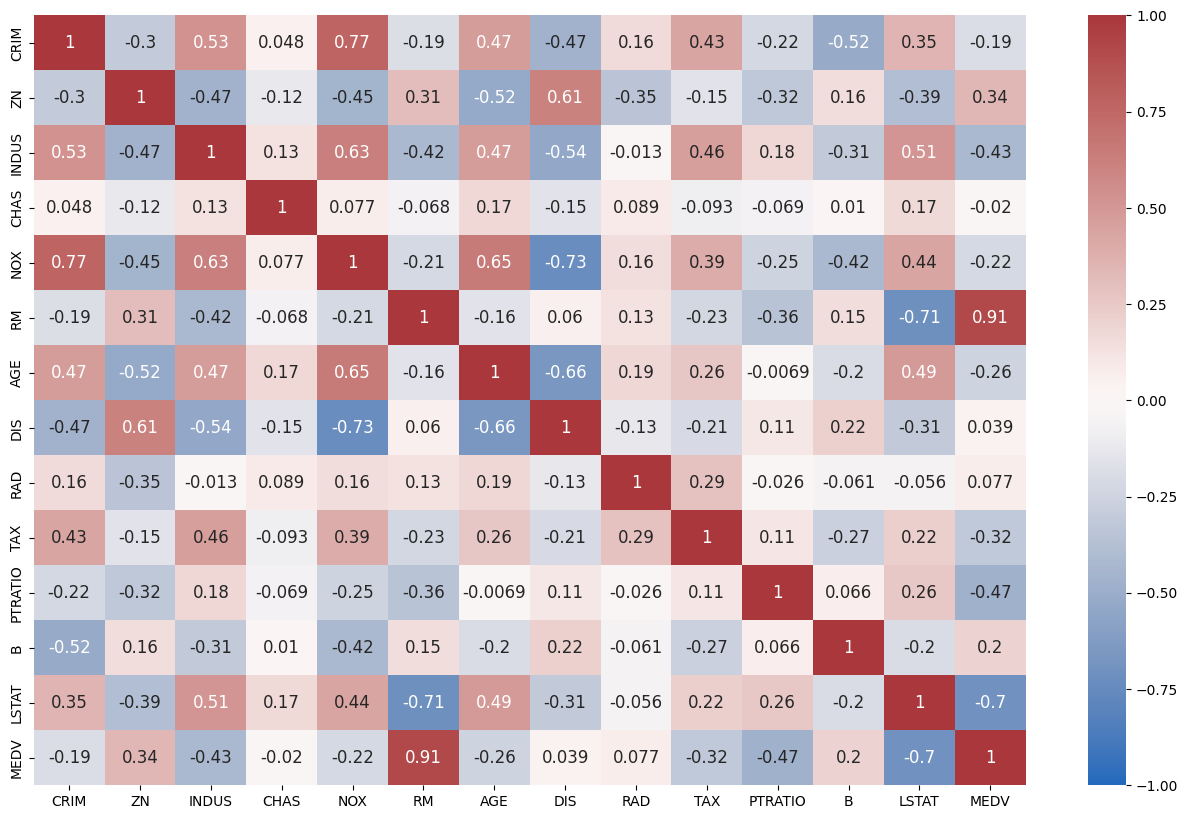

In [54]:
plt.subplots(figsize=(16, 10))
sns.heatmap(corr_mat, annot=True, annot_kws={'size': 12}, cmap='vlag',vmin=-1, vmax=1)

## Model Training

In [40]:
# Features (X)
X = df.drop(columns=["MEDV"])

# Target (y)
y = df["MEDV"]

In [57]:
X['Price'] = y


In [58]:
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='str')

In [ ]:
rows = 2
cols = 7

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 6))

col = X.columns
index = 0

for i in range(rows):
    for j in range(cols):
        ax[i][j].hist(X[col[index]])
        ax[i][j].set_title(col[index])
        index = index + 1

plt.tight_layout()
plt.show()

<Axes: xlabel='RM', ylabel='MEDV'>

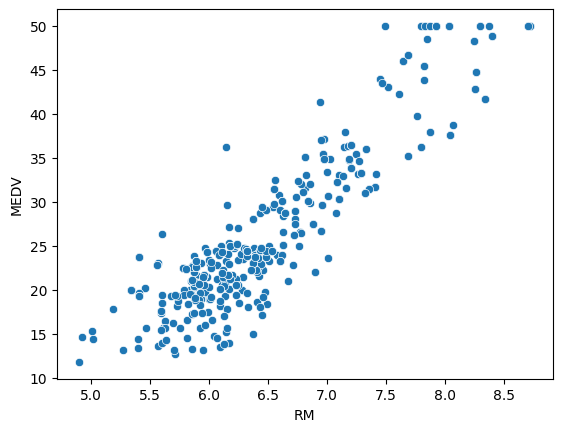

In [61]:
sns.scatterplot(data=df, x="RM", y="MEDV")


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


R² score: 0.8871


In [64]:
y_predict = model.predict(X_test)

In [65]:
y_predict, y_test

(array([13.77344419, 41.81077248, 14.67032441, 19.80605409, 27.72634332,
        25.96423658, 31.10187401, 24.98837431, 34.08254163, 18.4010675 ,
        19.12800765, 23.57497544, 23.04519268, 24.99464141, 20.32514014,
        26.37169025, 29.87025463, 26.29126861, 35.24218845, 31.68706128,
        23.56567032, 17.7346952 , 22.1577361 , 27.53056573, 27.40298952,
        22.21857927, 22.6988133 , 48.12031898, 46.32589349, 19.83575645,
        22.0434487 , 33.42060333, 38.40500441, 30.60218753, 44.21319019,
        22.25533601, 20.26214785, 23.30766568, 23.69063684,  9.36483099,
        20.2012915 , 33.86361409, 22.87447374, 12.55888914, 25.51414445,
        38.59954345, 12.9822995 , 25.48601267, 19.41740687, 26.3053569 ,
        21.83431176, 40.60990238, 21.0979019 , 28.2525993 , 22.69907768,
        29.91033961, 28.33441003, 18.15791409, 14.31526228, 10.53673552,
        20.72296697, 18.78470243, 20.2012915 , 22.88925854, 26.41383232,
        17.95192034, 41.08269193, 40.67737781, 40.6

## How to Evaluate the Regression Model Performance

The `coefficient of determination`, $R^2$, to quantify the model's performance. `The coefficient of determination` for a model is a useful statistic in `regression analysis`, as it often describes how "good" that model is at estimating/ calculating predictions.

The values for $R^2$ range from `0` to `1`, which captures the percentage of `squared correlation` between the predicted and actual values of the target variable:
- R² = 1.0 → perfect prediction of the target variable
- R² = 0.8 → model explains 80% of the variance
- R² = 0.0 → model is no better than predicting the mean
- R² < 0 → model is worse than a horizontal line, i.e. no better than one that naively predicts the `mean` of the target variable:

For the `performance_metric function` in the code cell below, you will need to implement the following:

We use r2_score from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`

In [76]:
r2= r2_score(y_test, y_predict) # coefficient of determination
print(f"R² score: {r2:.4f}")

R² score: 0.8871


In [77]:
mean_absolute_error(y_test, y_predict)


2.5263247566939504

In [72]:
mean_squared_error(y_test, y_predict)


9.434238571800398

In [73]:
np.sqrt(mean_squared_error(y_test, y_predict))


np.float64(3.071520563466961)

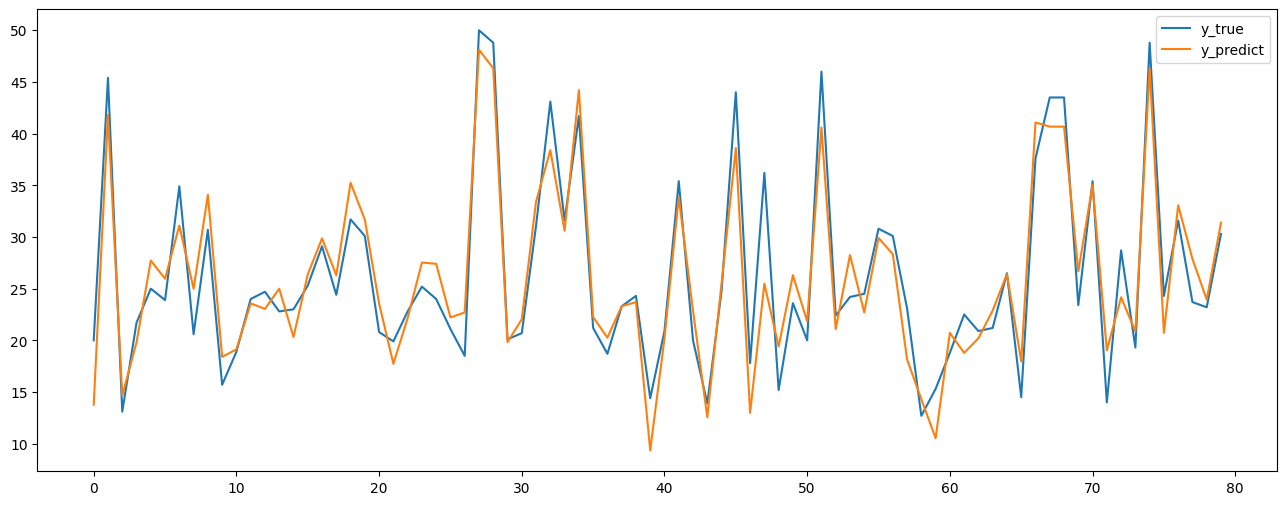

In [74]:
plt.subplots(figsize=(16,6))
x_points = list(range(len(y_test)))
plt.plot(x_points, y_test, label='y_true')
plt.plot(x_points, y_predict, label='y_predict')
plt.legend()
plt.show()

In [82]:
from sklearn.model_selection import learning_curve, ShuffleSplit


In [85]:
def plot_learning_curve(estimator, title, X,y, ylim=None, cv=None,
                       train_size=np.linspace(0.1, 1, 10)):
    plt.figure()
    plt.title(title)
    plt.xlabel('Traning Examples')
    plt.ylabel('score')

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_size)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)

    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean-train_scores_std,
                    train_scores_mean+train_scores_std, alpha=0.1, color='red')

    plt.fill_between(train_sizes, test_scores_mean-test_scores_std,
                    test_scores_mean+test_scores_std, alpha=0.1, color='green')

    plt.plot(train_sizes, train_scores_mean, 'o-', color='r',label='Training Score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Score')

    plt.legend(loc='best')



C:\Users\monta\AppData\Local\Temp\ipykernel_46852\2476218000.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


KeyboardInterrupt: 

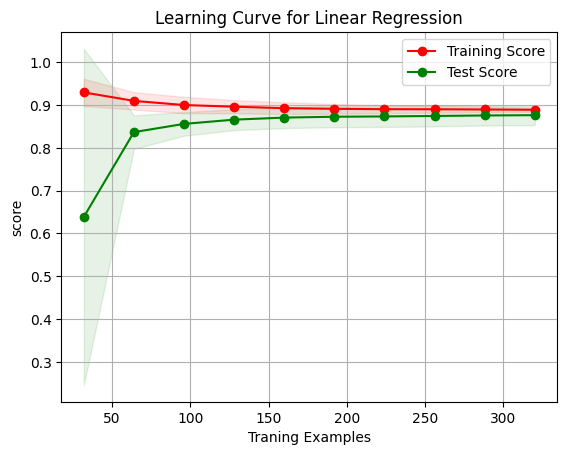

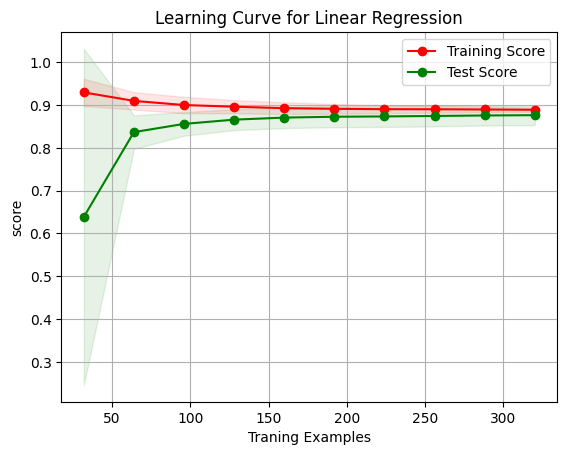

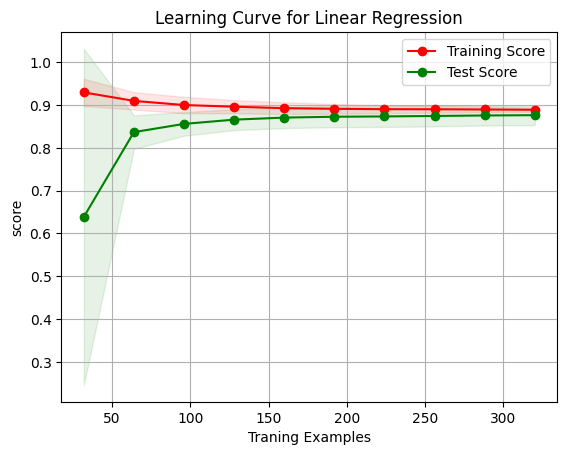

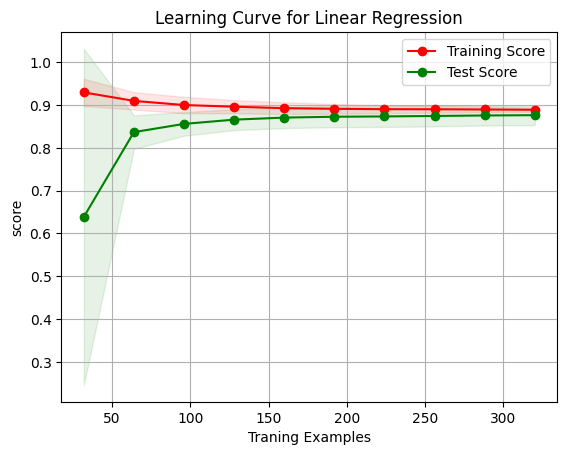

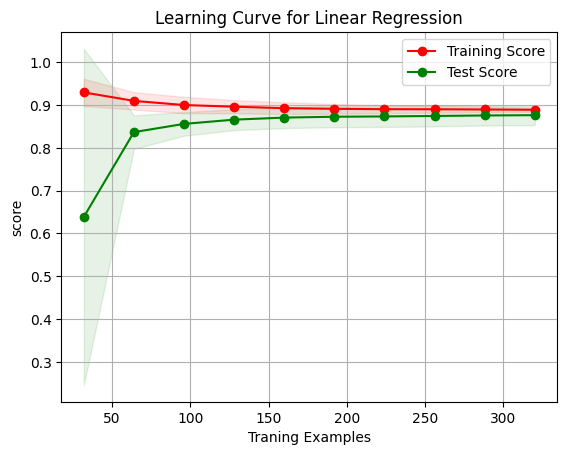

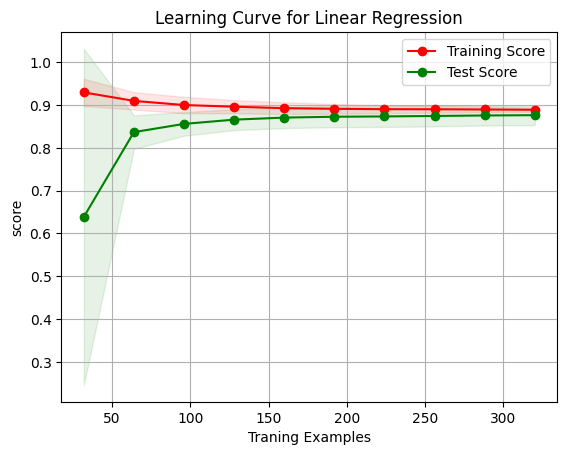

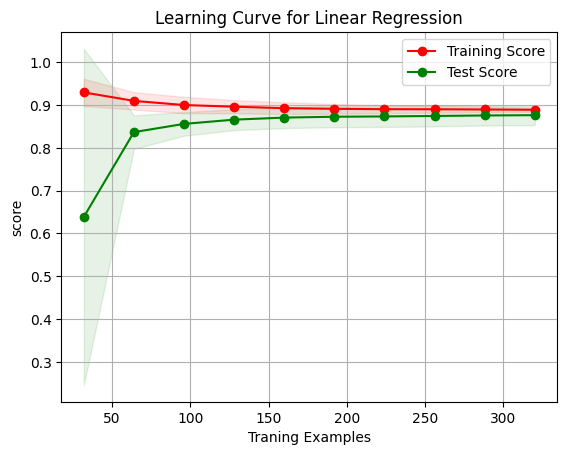

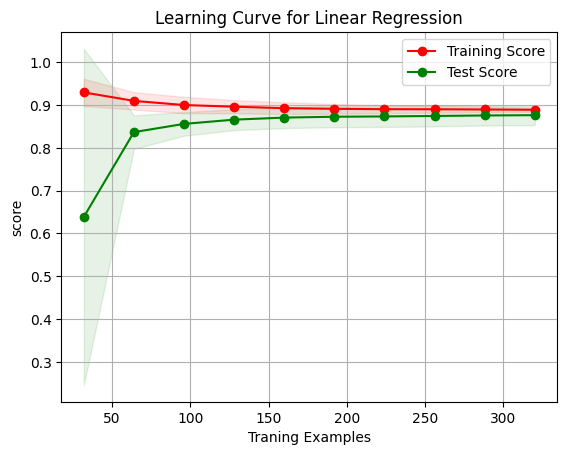

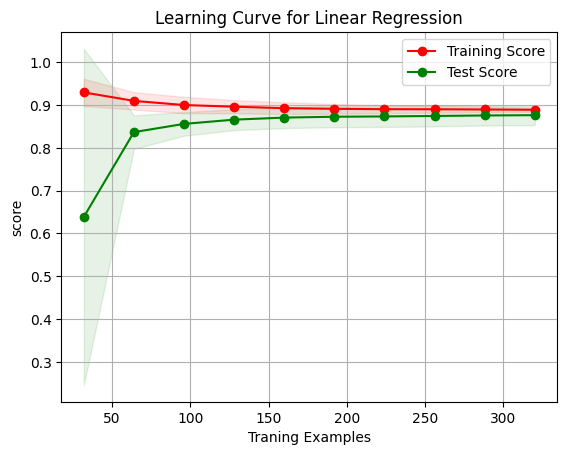

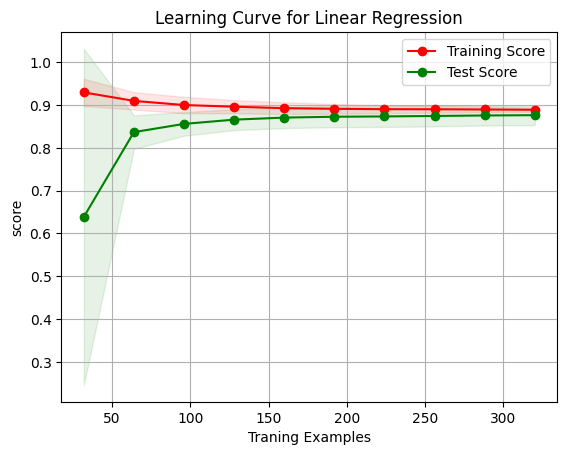

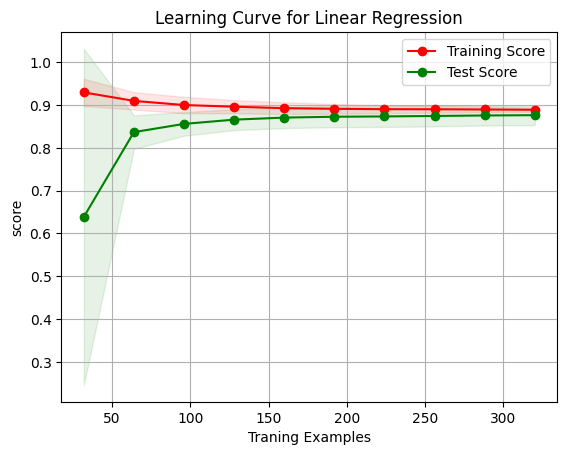

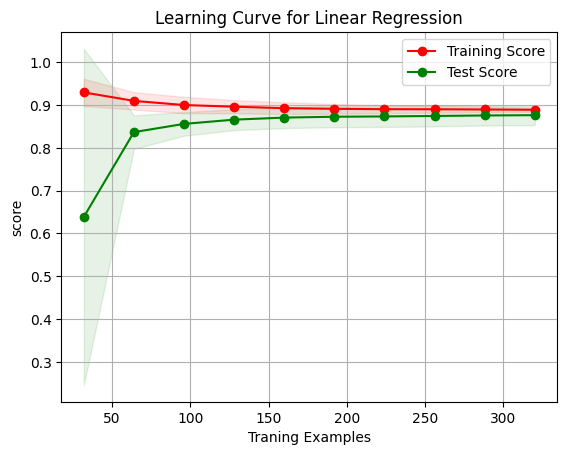

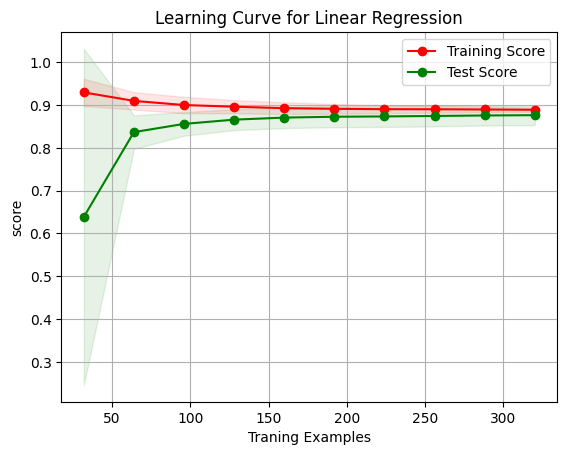

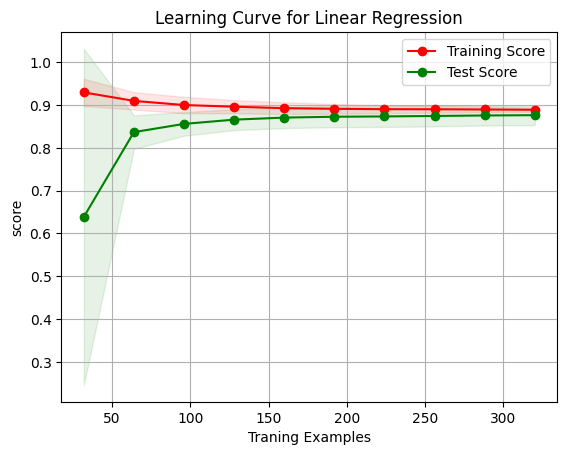

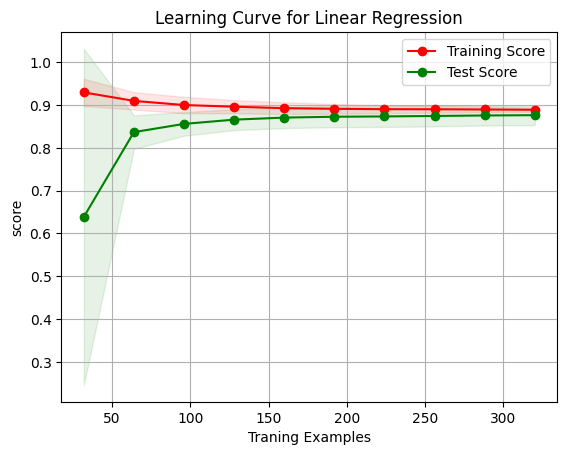

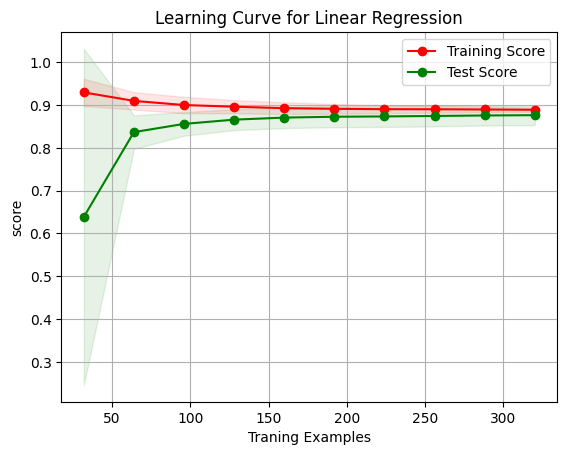

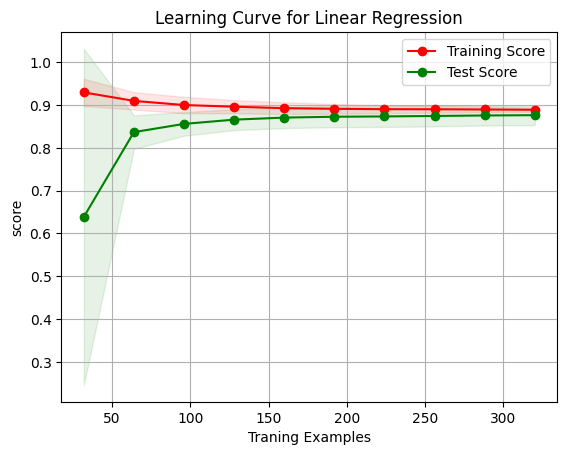

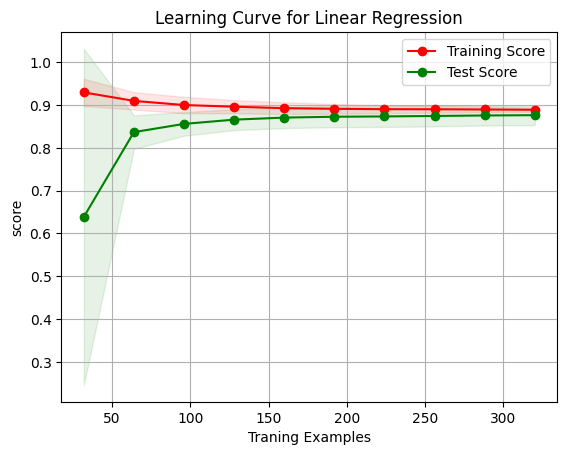

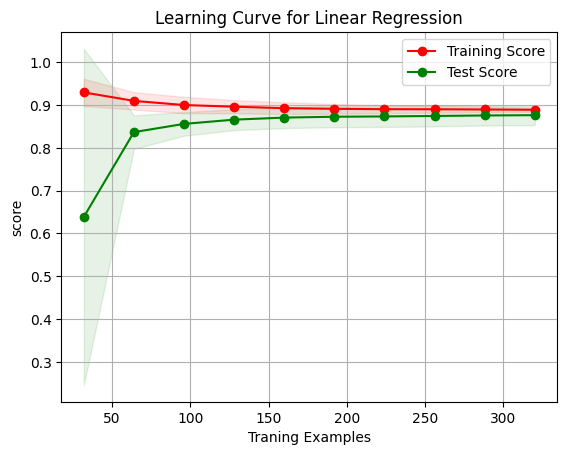

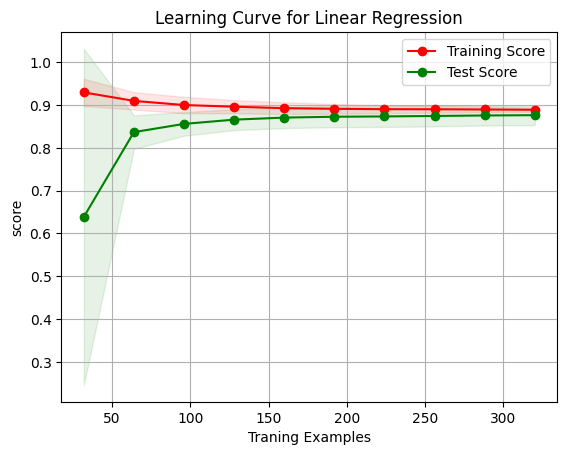

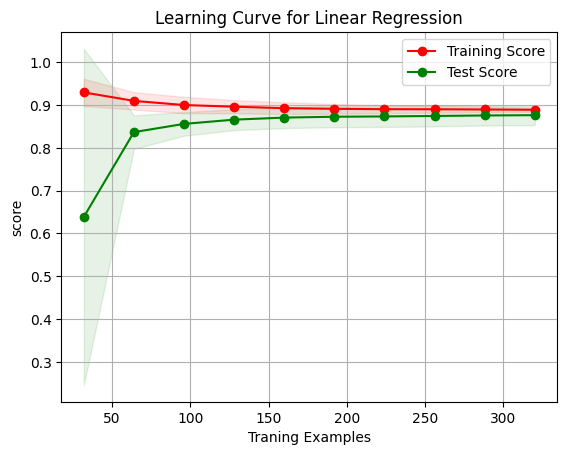

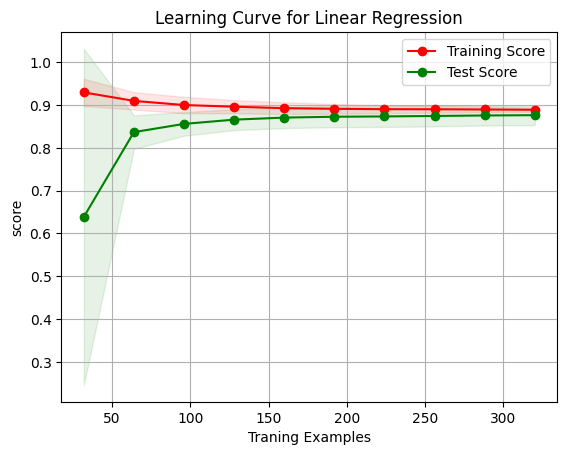

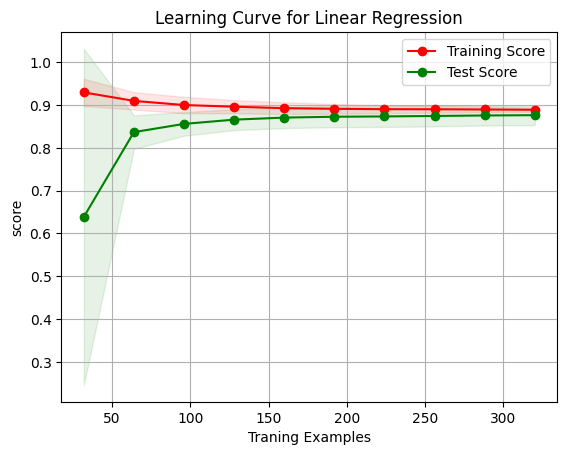

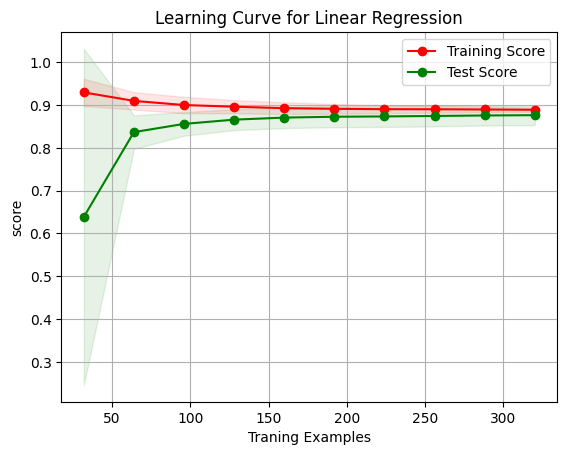

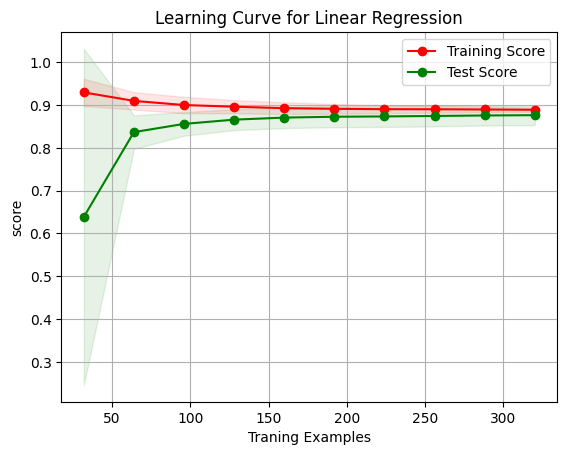

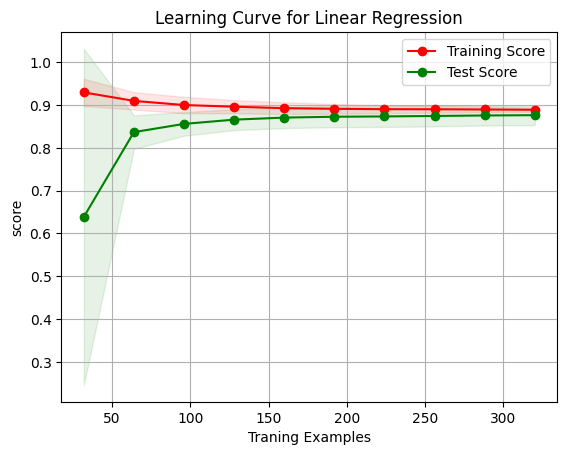

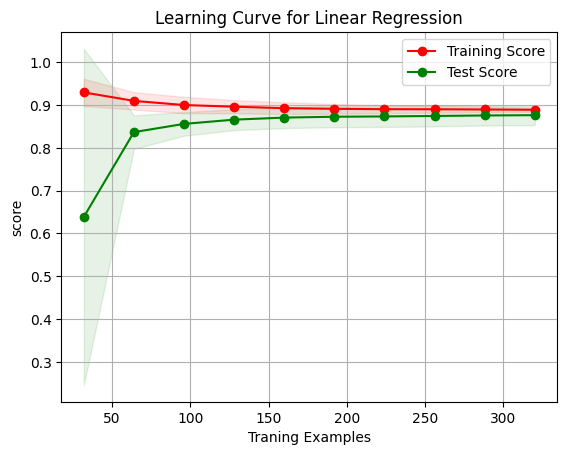

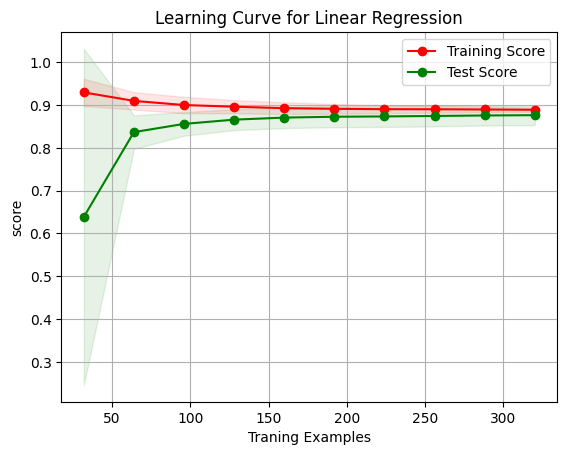

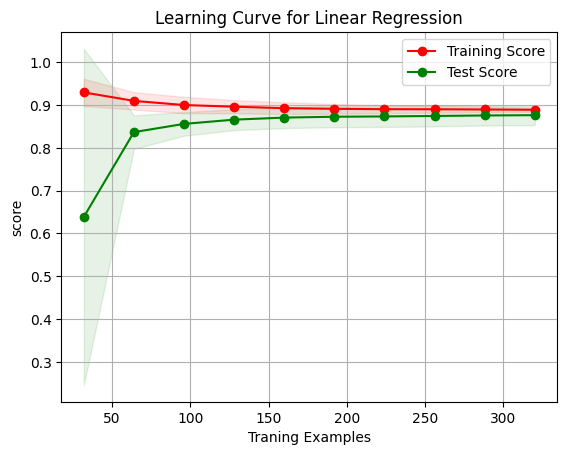

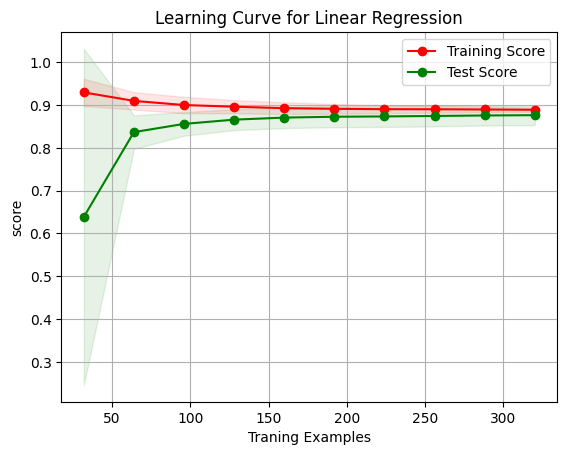

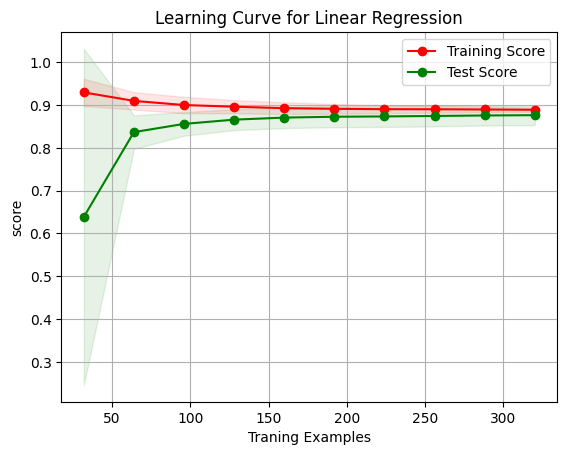

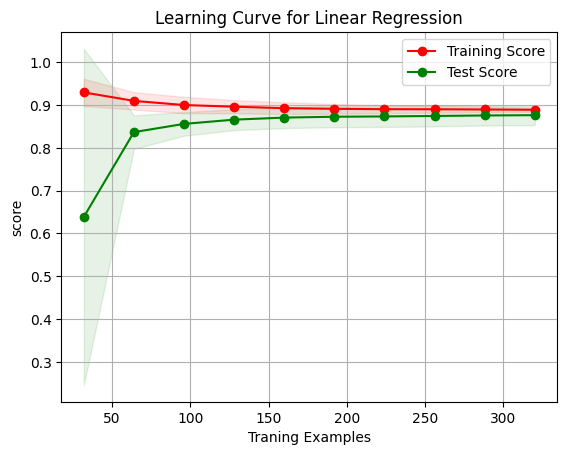

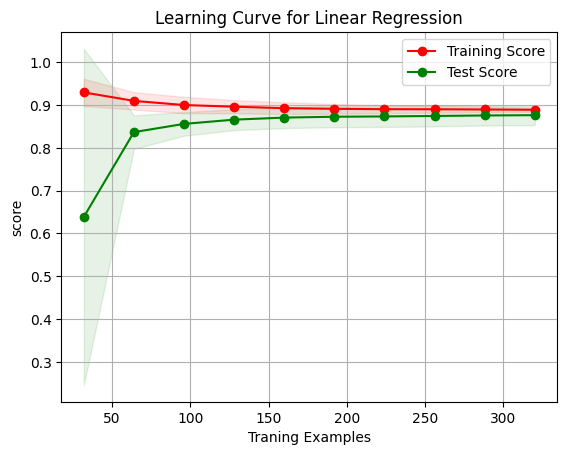

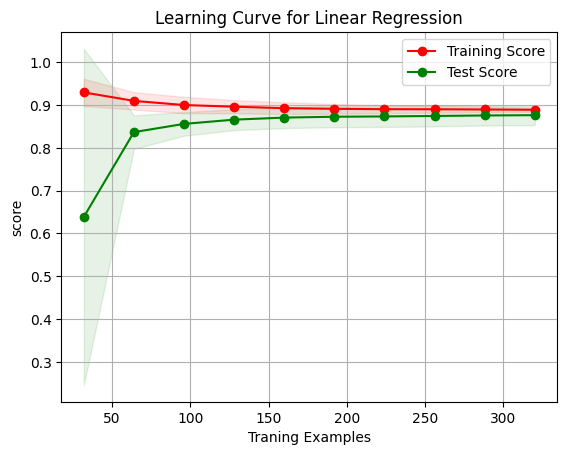

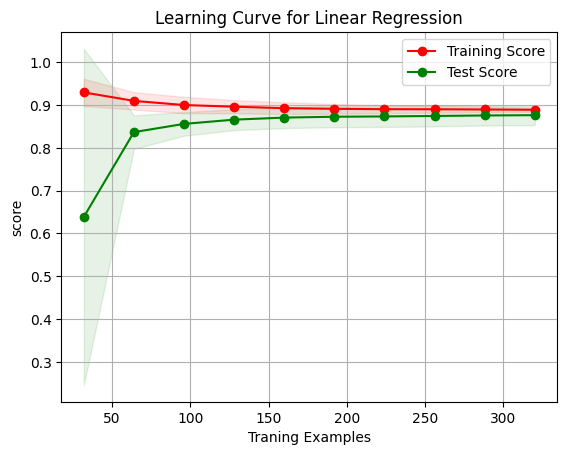

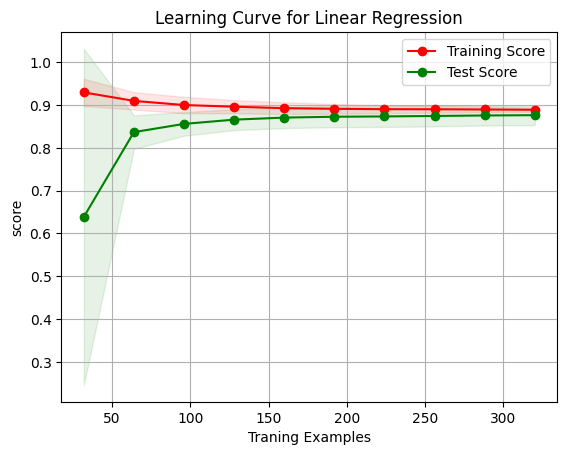

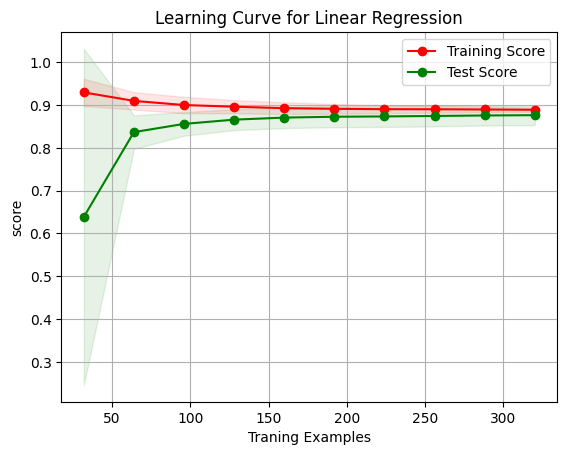

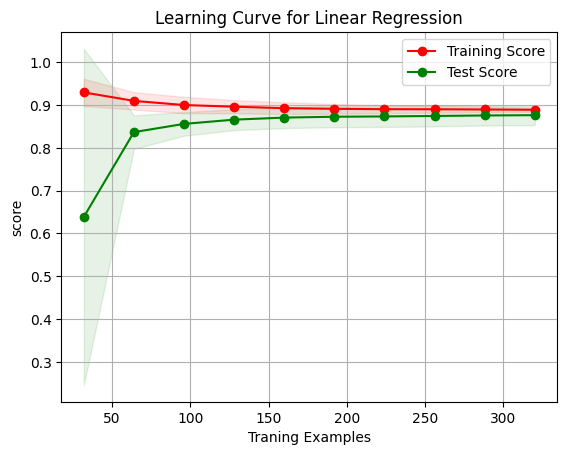

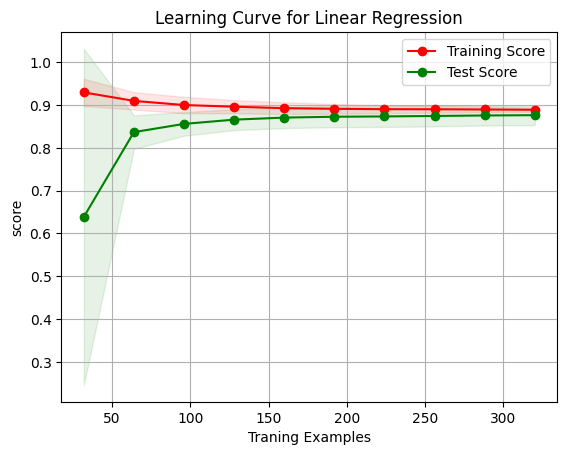

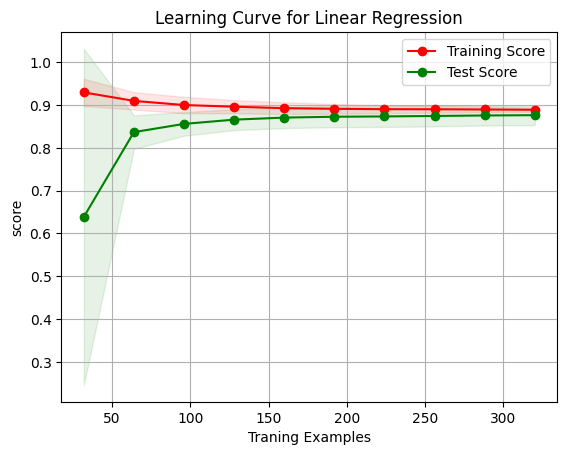

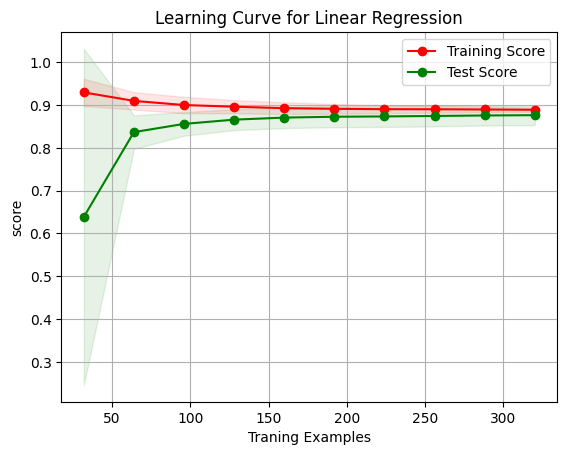

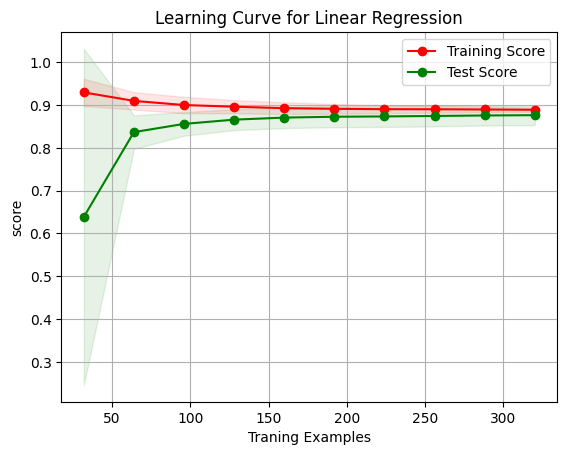

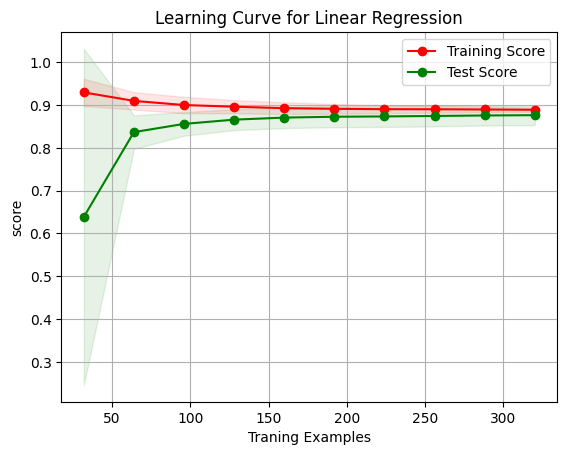

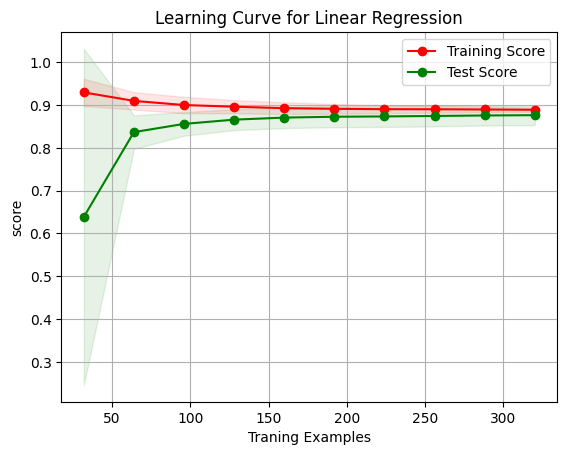

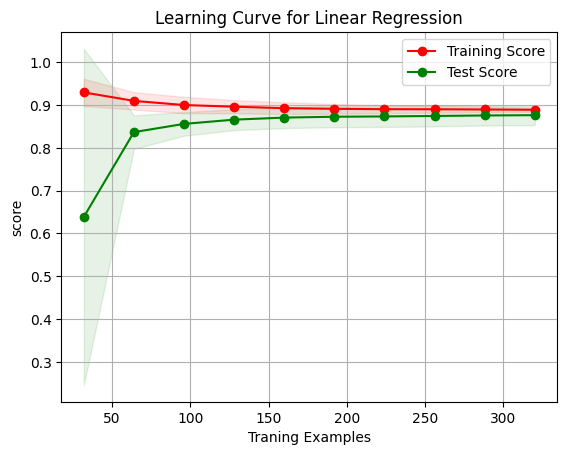

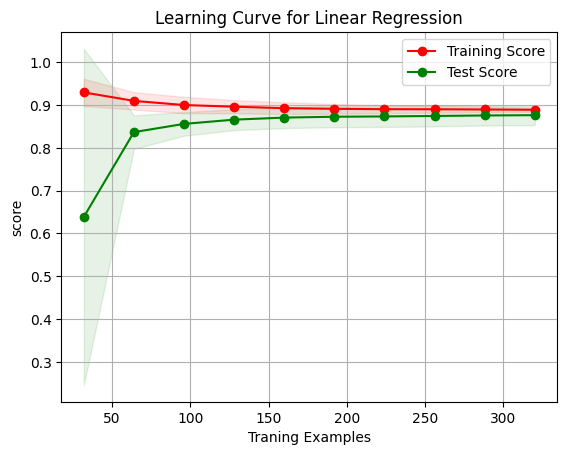

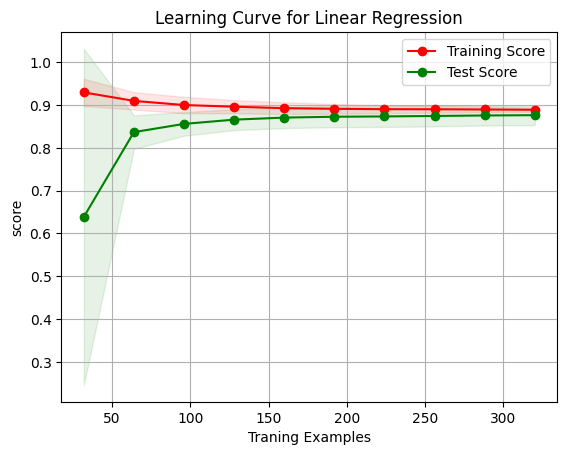

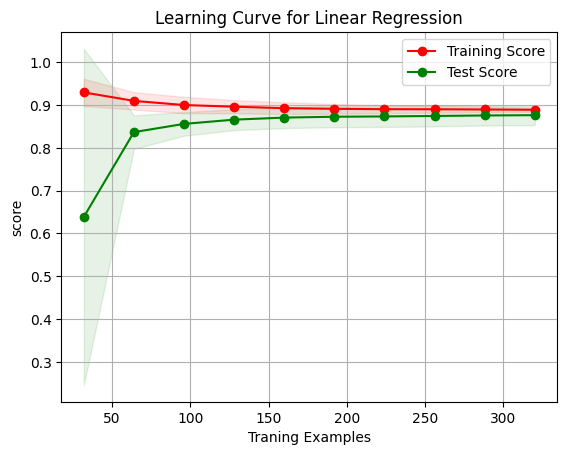

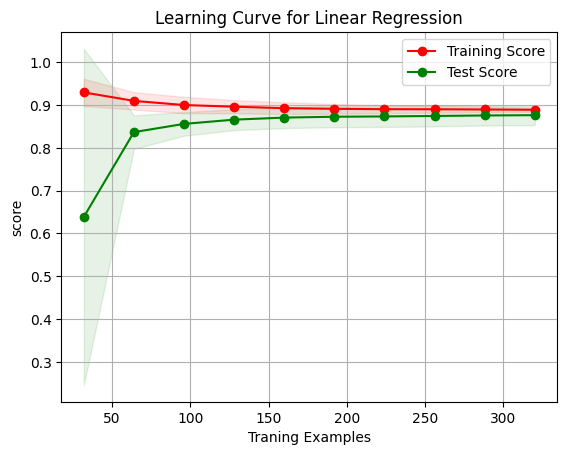

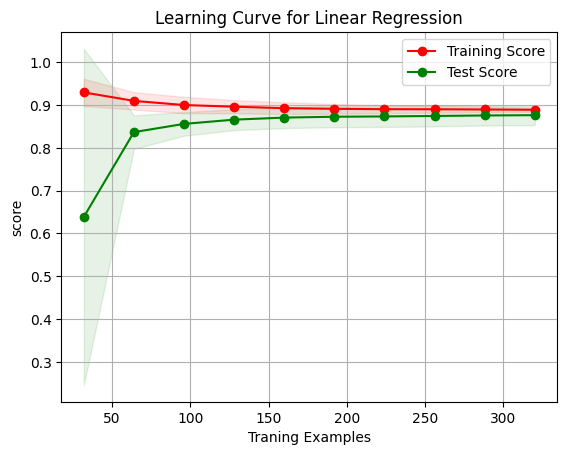

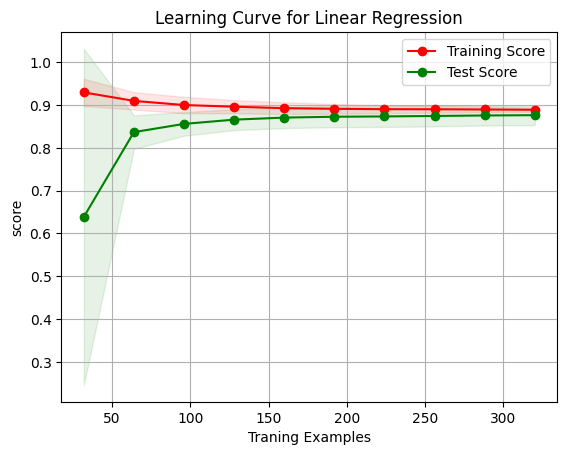

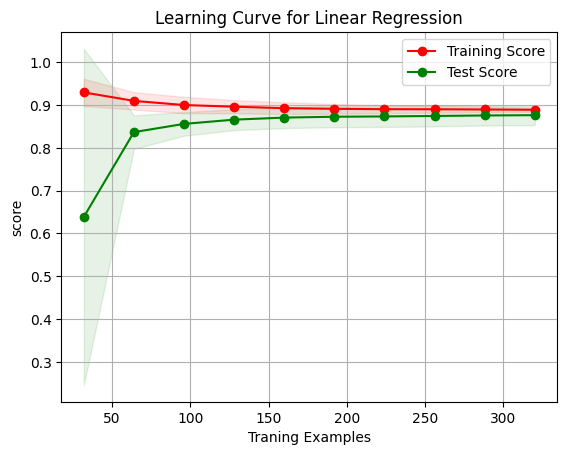

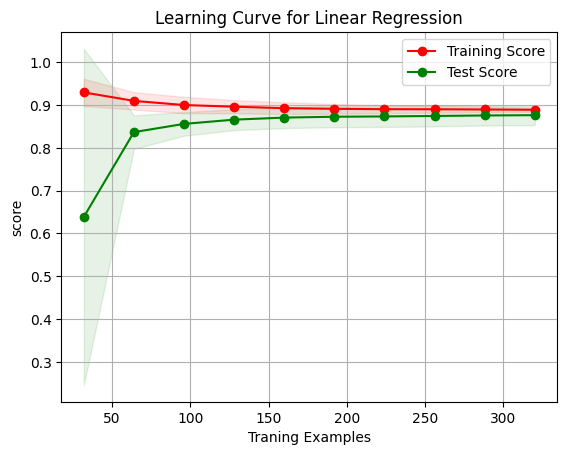

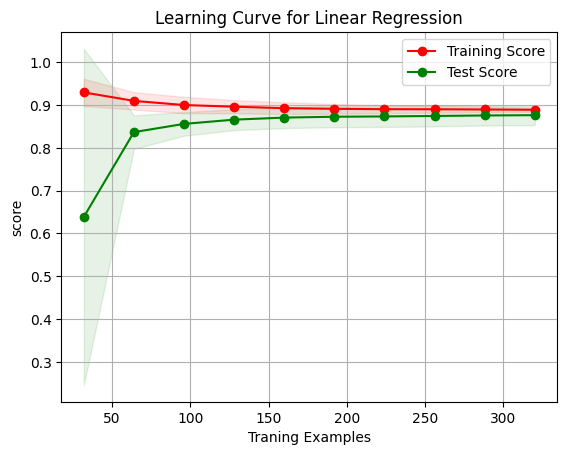

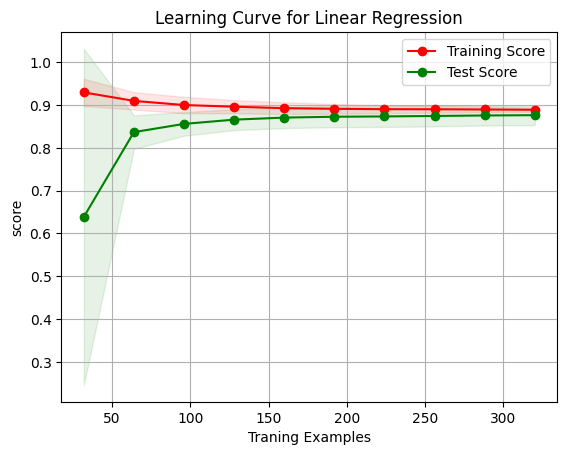

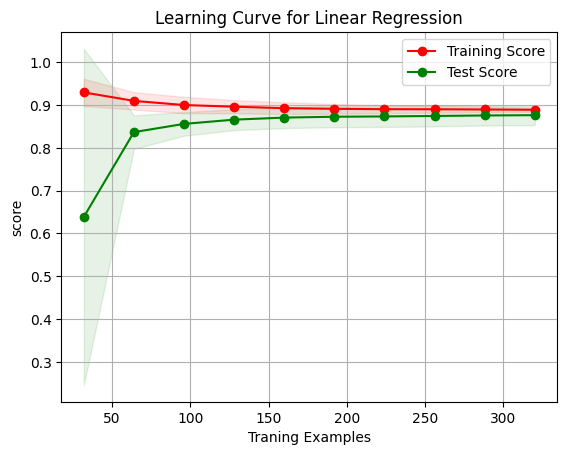

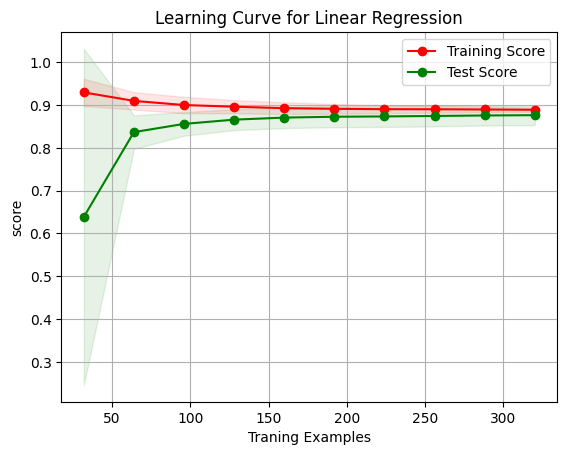

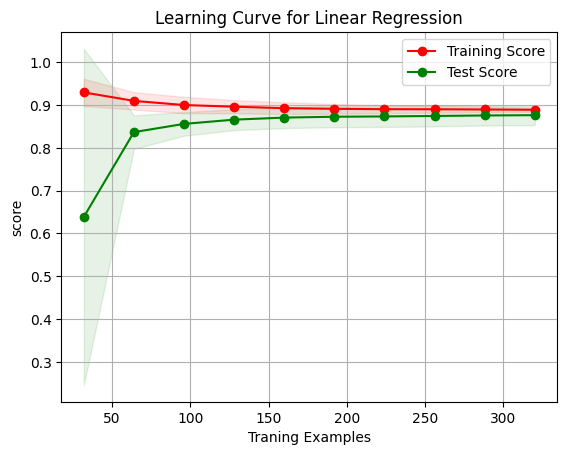

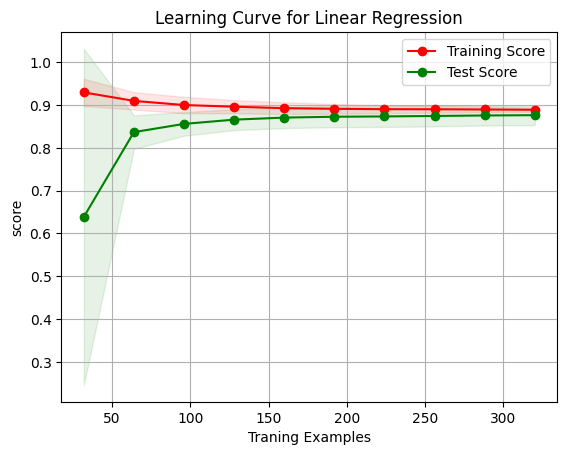

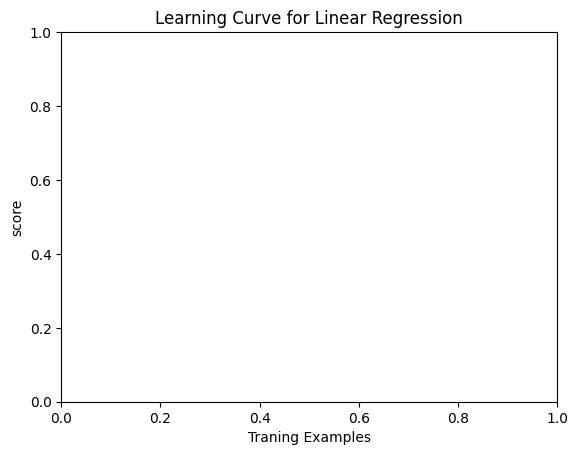

In [86]:
title = 'Learning Curve for Linear Regression'
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)
model = LinearRegression()
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv)
plt.show()

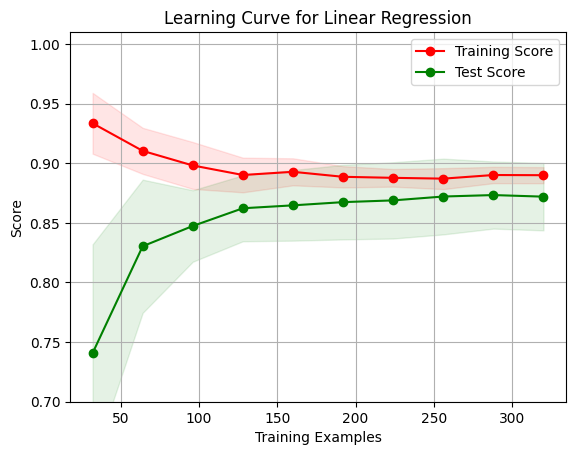

In [87]:


def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        train_size=np.linspace(0.1, 1, 10)):
    # 1. Clear previous figures from memory
    plt.clf()

    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel('Training Examples')
    plt.ylabel('Score')

    # 2. Added n_jobs=-1 to utilize multiple cores (optional but faster)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_size, n_jobs=-1)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='red')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='green')

    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Score')

    plt.legend(loc='best')
    plt.show() # 3. Properly display and flush the plot builder
    plt.close() # 4. Completely free up the memory used by this plot

# --- Execution ---
title = 'Learning Curve for Linear Regression'

# CRITICAL FIX: Lower n_splits from 100 to 5 or 10
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

model = LinearRegression()
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv)